In [1]:
# ================================================================
# Cell 0: SETUP (REPLACE THIS CELL)
# ================================================================
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dataset_path = Path("C:\\Users\\syedw\\Downloads\\AI SS26\\mlpc2026\\UE\\Task4\\MLPC2026_dataset_development")
npz_files = sorted((dataset_path / 'audio_features').glob('*.npz'))
print(f"Found {len(npz_files)} npz files")

FEATURE_KEYS = [
    'zcr_mean', 'zcr_std', 'zcr_min', 'zcr_max',
    'melspect_mean', 'melspect_std', 'melspect_min', 'melspect_max',
    'mfcc_mean', 'mfcc_std', 'mfcc_min', 'mfcc_max',
    'mfcc_d_mean', 'mfcc_d_std', 'mfcc_d_min', 'mfcc_d_max',
    'mfcc_d2_mean', 'mfcc_d2_std', 'mfcc_d2_min', 'mfcc_d2_max',
    'flux_mean', 'flux_std', 'flux_min', 'flux_max',
    'flatness_mean', 'flatness_std', 'flatness_min', 'flatness_max',
    'centroid_mean', 'centroid_std', 'centroid_min', 'centroid_max',
    'bandwidth_mean', 'bandwidth_std', 'bandwidth_min', 'bandwidth_max',
    'contrast_mean', 'contrast_std', 'contrast_min', 'contrast_max',
    'rolloff_low_mean', 'rolloff_low_std', 'rolloff_low_min', 'rolloff_low_max',
    'rolloff_high_mean', 'rolloff_high_std', 'rolloff_high_min', 'rolloff_high_max',
    'energy_mean', 'energy_std', 'energy_min', 'energy_max',
    'power_mean', 'power_std', 'power_min', 'power_max',
]

Found 3656 npz files


In [2]:
# ================================================================
# 1(a) LABEL AGGREGATION
# ================================================================
# Binarize at >= 0.5, majority vote (votes > A/2)
# EXCLUDING files with only 1 annotator (no majority vote possible)

def aggregate_labels(annotations):
    A = annotations.shape[2]
    binary = (annotations >= 0.5).astype(int)
    labels = (binary.sum(axis=2) > A / 2).astype(int)
    return labels

def load_single_features(filepath):
    data = np.load(filepath, allow_pickle=True)
    feats = []
    for key in FEATURE_KEYS:
        feat = data[key]
        if feat.ndim > 1:
            feats.append(feat.reshape(feat.shape[0], -1))
        else:
            feats.append(feat.reshape(-1, 1))
    return np.hstack(feats)

# Filter: keep only files with >= 2 annotators
valid_files = []
skipped = 0
for f in npz_files:
    data = np.load(f, allow_pickle=True)
    A = data['annotations'].shape[2]
    if A >= 2:
        valid_files.append(f)
    else:
        skipped += 1

# Get class names
data = np.load(valid_files[0], allow_pickle=True)
class_names = list(data['class_names'])

print(f"Valid files (>= 2 annotators): {len(valid_files)}")
print(f"Excluded files (1 annotator):  {skipped}")

# Load all data
def load_data(file_list):
    X_list, y_list = [], []
    for f in file_list:
        data = np.load(f, allow_pickle=True)
        X_list.append(load_single_features(f))
        y_list.append(aggregate_labels(data['annotations']))
    return np.vstack(X_list), np.vstack(y_list)

Valid files (>= 2 annotators): 3031
Excluded files (1 annotator):  625


In [3]:
# ================================================================
# 1(b) DATA SPLIT — file-level
# ================================================================
# Split at FILE level: segments from the same recording stay together
# because consecutive segments overlap by 0.5s (shared audio content).
# Split: 70% train, 15% val, 15% test

indices = np.arange(len(valid_files))
train_idx, temp_idx = train_test_split(indices, test_size=0.3, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_files = [valid_files[i] for i in train_idx]
val_files = [valid_files[i] for i in val_idx]
test_files = [valid_files[i] for i in test_idx]

print(f"Train files: {len(train_files)}, Val files: {len(val_files)}, Test files: {len(test_files)}")

print("\nLoading train data...")
X_train, Y_train = load_data(train_files)
print("Loading val data...")
X_val, Y_val = load_data(val_files)
print("Loading test data...")
X_test, Y_test = load_data(test_files)

# Track filenames for case study later
filenames_test = []
for f in test_files:
    data = np.load(f, allow_pickle=True)
    T = data['annotations'].shape[0]
    fname = f.stem + '.wav'
    filenames_test.extend([fname] * T)
filenames_test = np.array(filenames_test)

print(f"\nX_train: {X_train.shape}, Y_train: {Y_train.shape}")
print(f"X_val:   {X_val.shape},   Y_val:   {Y_val.shape}")
print(f"X_test:  {X_test.shape},  Y_test:  {Y_test.shape}")
total = len(X_train) + len(X_val) + len(X_test)
print(f"Total segments: {total}")

# Verify no file leakage
train_set = set(str(f) for f in train_files)
val_set = set(str(f) for f in val_files)
test_set = set(str(f) for f in test_files)
print(f"\nLeakage: T∩V={len(train_set & val_set)} T∩Te={len(train_set & test_set)} V∩Te={len(val_set & test_set)}")

# Class distribution
print(f"\n{'Class':<35} {'Train%':>7} {'Val%':>7} {'Test%':>7}")
print("-" * 58)
for i, name in enumerate(class_names):
    tr = Y_train[:, i].mean() * 100
    va = Y_val[:, i].mean() * 100
    te = Y_test[:, i].mean() * 100
    print(f"  {name:<33} {tr:6.2f}% {va:6.2f}% {te:6.2f}%")


Train files: 2121, Val files: 455, Test files: 455

Loading train data...
Loading val data...
Loading test data...

X_train: (97391, 960), Y_train: (97391, 15)
X_val:   (20976, 960),   Y_val:   (20976, 15)
X_test:  (20892, 960),  Y_test:  (20892, 15)
Total segments: 139259

Leakage: T∩V=0 T∩Te=0 V∩Te=0

Class                                Train%    Val%   Test%
----------------------------------------------------------
  bell_ringing                        1.14%   1.32%   1.54%
  coffee_machine                      3.50%   4.36%   3.70%
  cutlery_dishes                      5.49%   6.18%   6.10%
  door_open_close                     3.30%   3.33%   3.21%
  footsteps                          11.56%  11.35%  11.09%
  keyboard_typing                     9.33%   9.21%   7.85%
  keychain                            4.48%   4.02%   4.99%
  light_switch                        0.26%   0.26%   0.26%
  microwave                           6.83%   6.85%   7.28%
  phone_ringing                     

In [4]:
# ================================================================
# Cell 3: PREPROCESSING (REPLACE THIS CELL)
# ================================================================
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# PCA: reduce 960 features to components capturing 95% of variance
pca = PCA(n_components=0.95, random_state=42)
X_train_scaled = pca.fit_transform(X_train_scaled)
X_val_scaled = pca.transform(X_val_scaled)
X_test_scaled = pca.transform(X_test_scaled)

n_components = X_train_scaled.shape[1]
print(f"PCA: 960 features → {n_components} components (95% variance retained)")
print(f"Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")

PCA: 960 features → 238 components (95% variance retained)
Train mean: -0.000000, std: 1.957570


In [5]:
# Track filenames for case study later
filenames_test = []
for f in test_files:
    data = np.load(f, allow_pickle=True)
    T = data['annotations'].shape[0]
    fname = f.stem + '.wav'
    filenames_test.extend([fname] * T)
filenames_test = np.array(filenames_test)

print(f"\nX_train: {X_train_scaled.shape}, Y_train: {Y_train.shape}")
print(f"X_val:   {X_val_scaled.shape},   Y_val:   {Y_val.shape}")
print(f"X_test:  {X_test_scaled.shape},  Y_test:  {Y_test.shape}")
total = len(X_train) + len(X_val) + len(X_test)
print(f"Total segments: {total}")


X_train: (97391, 238), Y_train: (97391, 15)
X_val:   (20976, 238),   Y_val:   (20976, 15)
X_test:  (20892, 238),  Y_test:  (20892, 15)
Total segments: 139259


In [6]:
# ================================================================
# QUESTION 2(a): EVALUATION METRIC
# ================================================================
from sklearn.metrics import f1_score, balanced_accuracy_score

train_freqs = Y_train.mean(axis=0)

print("=" * 60)
print("2(a) EVALUATION METRIC")
print("=" * 60)
print(f"Most frequent:  {class_names[train_freqs.argmax()]} ({train_freqs.max()*100:.2f}%)")
print(f"Least frequent: {class_names[train_freqs.argmin()]} ({train_freqs.min()*100:.2f}%)")
print(f"Imbalance ratio: {train_freqs.max()/train_freqs.min():.1f}x")

print("\n'Always predict 0' accuracy per class (why accuracy is bad):")
for i, name in enumerate(class_names):
    print(f"  {name:35s}: {(1 - Y_val[:,i].mean())*100:.2f}%")

2(a) EVALUATION METRIC
Most frequent:  running_water (11.96%)
Least frequent: light_switch (0.26%)
Imbalance ratio: 46.4x

'Always predict 0' accuracy per class (why accuracy is bad):
  bell_ringing                       : 98.68%
  coffee_machine                     : 95.64%
  cutlery_dishes                     : 93.82%
  door_open_close                    : 96.67%
  footsteps                          : 88.65%
  keyboard_typing                    : 90.79%
  keychain                           : 95.98%
  light_switch                       : 99.74%
  microwave                          : 93.15%
  phone_ringing                      : 93.00%
  running_water                      : 88.16%
  toilet_flushing                    : 97.46%
  vacuum_cleaner                     : 92.86%
  wardrobe_drawer_open_close         : 98.28%
  window_open_close                  : 98.56%


In [7]:
# ================================================================
# QUESTION 2(b): BASELINE PERFORMANCE
# ================================================================

def evaluate(y_true, y_pred):
    f1s = [f1_score(y_true[:, c], y_pred[:, c], zero_division=0) for c in range(y_true.shape[1])]
    bals = [balanced_accuracy_score(y_true[:, c], y_pred[:, c]) for c in range(y_true.shape[1])]
    return np.array(f1s), np.mean(f1s), np.array(bals), np.mean(bals)

# Baseline 1: Always predict 0
Y_pred_zeros = np.zeros_like(Y_val)
_, zeros_f1, _, zeros_bal = evaluate(Y_val, Y_pred_zeros)

# Baseline 2: Random using training frequencies
np.random.seed(42)
Y_pred_random = np.zeros_like(Y_val)
for c in range(len(class_names)):
    Y_pred_random[:, c] = np.random.binomial(1, train_freqs[c], size=len(Y_val))
rand_f1s, rand_macro_f1, _, rand_macro_bal = evaluate(Y_val, Y_pred_random)

print("=" * 60)
print("2(b) BASELINE PERFORMANCE (on validation set)")
print("=" * 60)
print(f"\nBaseline 1 — Always predict 0:  Macro F1 = {zeros_f1:.4f}")
print(f"Baseline 2 — Random:            Macro F1 = {rand_macro_f1:.4f}")

print(f"\nPer-class (Baseline 2):")
print(f"  {'Class':<35} {'Freq':>6} {'F1':>8}")
print(f"  {'-'*50}")
for i, name in enumerate(class_names):
    print(f"  {name:<35} {train_freqs[i]:.4f} {rand_f1s[i]:.4f}")

print(f"\nBest possible: F1 < 0.85 (noisy labels, annotator disagreement)")

2(b) BASELINE PERFORMANCE (on validation set)

Baseline 1 — Always predict 0:  Macro F1 = 0.0000
Baseline 2 — Random:            Macro F1 = 0.0506

Per-class (Baseline 2):
  Class                                 Freq       F1
  --------------------------------------------------
  bell_ringing                        0.0114 0.0116
  coffee_machine                      0.0350 0.0365
  cutlery_dishes                      0.0549 0.0487
  door_open_close                     0.0330 0.0287
  footsteps                           0.1156 0.1132
  keyboard_typing                     0.0933 0.0897
  keychain                            0.0448 0.0428
  light_switch                        0.0026 0.0000
  microwave                           0.0683 0.0738
  phone_ringing                       0.0579 0.0660
  running_water                       0.1196 0.1259
  toilet_flushing                     0.0317 0.0222
  vacuum_cleaner                      0.0636 0.0619
  wardrobe_drawer_open_close          0.0188 

CLASSIFIER 1: RANDOM FOREST (class_weight='balanced')
  max_depth=10, min_samples_leaf=5... Macro F1=0.4416, BalAcc=0.7554
  max_depth=20, min_samples_leaf=5... Macro F1=0.3510, BalAcc=0.6280
  max_depth=30, min_samples_leaf=5... Macro F1=0.2923, BalAcc=0.5995

Best RF: max_depth=10, min_samples_leaf=5, F1=0.4416


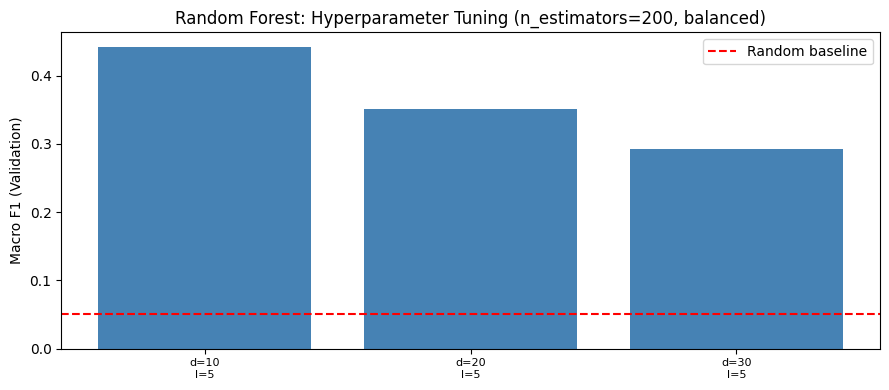


CLASSIFIER 2: K-NEAREST NEIGHBORS
Using subsample of 20000 segments for KNN
  k=3, weights=uniform... Macro F1=0.3680, BalAcc=0.6416
  k=3, weights=distance... Macro F1=0.3680, BalAcc=0.6416
  k=5, weights=uniform... Macro F1=0.3545, BalAcc=0.6322
  k=5, weights=distance... Macro F1=0.3545, BalAcc=0.6322
  k=11, weights=uniform... Macro F1=0.3183, BalAcc=0.6153
  k=11, weights=distance... Macro F1=0.3184, BalAcc=0.6153
  k=21, weights=uniform... Macro F1=0.2805, BalAcc=0.6005
  k=21, weights=distance... Macro F1=0.2805, BalAcc=0.6005

Best KNN: k=3, weights=uniform, F1=0.3680


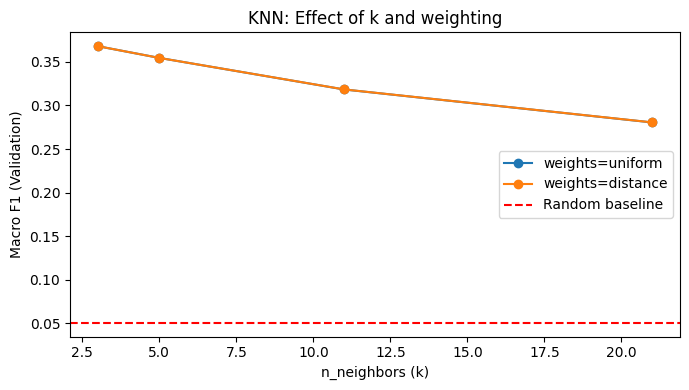

In [8]:
# ================================================================
# QUESTION 3(a): EXPERIMENTS
# ================================================================
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.multioutput import MultiOutputClassifier

# ================================================================
# CLASSIFIER 1: RANDOM FOREST (with class_weight='balanced')
# ================================================================
print("=" * 60)
print("CLASSIFIER 1: RANDOM FOREST (class_weight='balanced')")
print("=" * 60)

rf_results = []
for depth in [10, 20, 30]:
    for leaf in [5]:
        print(f"  max_depth={depth}, min_samples_leaf={leaf}...", end=" ")
        clf = MultiOutputClassifier(
            RandomForestClassifier(n_estimators=200, max_depth=depth,
                                   min_samples_leaf=leaf,
                                   class_weight='balanced',
                                   random_state=42, n_jobs=-1)
        )
        clf.fit(X_train_scaled, Y_train)
        Y_pred = clf.predict(X_val_scaled)
        _, macro_f1, _, macro_bal = evaluate(Y_val, Y_pred)
        rf_results.append({'depth': depth, 'leaf': leaf, 'f1': macro_f1, 'bal': macro_bal})
        print(f"Macro F1={macro_f1:.4f}, BalAcc={macro_bal:.4f}")

best_rf = max(rf_results, key=lambda x: x['f1'])
print(f"\nBest RF: max_depth={best_rf['depth']}, min_samples_leaf={best_rf['leaf']}, F1={best_rf['f1']:.4f}")

# Visualization
fig, ax = plt.subplots(figsize=(9, 4))
labels = [f"d={r['depth']}\nl={r['leaf']}" for r in rf_results]
scores = [r['f1'] for r in rf_results]
ax.bar(range(len(labels)), scores, color='steelblue')
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.axhline(y=rand_macro_f1, color='red', linestyle='--', label='Random baseline')
ax.set_ylabel('Macro F1 (Validation)')
ax.set_title('Random Forest: Hyperparameter Tuning (n_estimators=200, balanced)')
ax.legend()
plt.tight_layout()
plt.savefig('rf_hyperparameters.png', dpi=150)
plt.show()

# ================================================================
# CLASSIFIER 2: K-NEAREST NEIGHBORS
# ================================================================
print("\n" + "=" * 60)
print("CLASSIFIER 2: K-NEAREST NEIGHBORS")
print("=" * 60)

sample_size = 20000
np.random.seed(42)
knn_idx = np.random.choice(len(X_train_scaled), size=sample_size, replace=False)
X_train_knn = X_train_scaled[knn_idx]
Y_train_knn = Y_train[knn_idx]
print(f"Using subsample of {sample_size} segments for KNN")

knn_results = []
for k in [3, 5, 11, 21]:
    for w in ['uniform', 'distance']:
        print(f"  k={k}, weights={w}...", end=" ")
        clf = MultiOutputClassifier(
            KNeighborsClassifier(n_neighbors=k, weights=w, n_jobs=-1)
        )
        clf.fit(X_train_knn, Y_train_knn)
        Y_pred = clf.predict(X_val_scaled)
        _, macro_f1, _, macro_bal = evaluate(Y_val, Y_pred)
        knn_results.append({'k': k, 'w': w, 'f1': macro_f1, 'bal': macro_bal})
        print(f"Macro F1={macro_f1:.4f}, BalAcc={macro_bal:.4f}")

best_knn = max(knn_results, key=lambda x: x['f1'])
print(f"\nBest KNN: k={best_knn['k']}, weights={best_knn['w']}, F1={best_knn['f1']:.4f}")

# KNN visualization
fig, ax = plt.subplots(figsize=(7, 4))
for w in ['uniform', 'distance']:
    subset = [r for r in knn_results if r['w'] == w]
    ax.plot([r['k'] for r in subset], [r['f1'] for r in subset], marker='o', label=f'weights={w}')
ax.axhline(y=rand_macro_f1, color='red', linestyle='--', label='Random baseline')
ax.set_xlabel('n_neighbors (k)')
ax.set_ylabel('Macro F1 (Validation)')
ax.set_title('KNN: Effect of k and weighting')
ax.legend()
plt.tight_layout()
plt.savefig('knn_hyperparameters.png', dpi=150)
plt.show()

In [11]:
# ================================================================
# QUESTION 3(b): FINAL COMPARISON ON TEST SET
# ================================================================
print("=" * 60)
print("FINAL COMPARISON ON TEST SET")
print("=" * 60)

# Best RF
print("Training best RF...")
best_rf_clf = MultiOutputClassifier(
    RandomForestClassifier(n_estimators=200, max_depth=best_rf['depth'],
                           min_samples_leaf=best_rf['leaf'],
                           class_weight='balanced',
                           random_state=42, n_jobs=-1)
)
best_rf_clf.fit(X_train_scaled, Y_train)
Y_pred_rf_test = best_rf_clf.predict(X_test_scaled)
rf_f1s, rf_macro_f1, _, rf_macro_bal = evaluate(Y_test, Y_pred_rf_test)

# Best KNN
print("Training best KNN...")
best_knn_clf = MultiOutputClassifier(
    KNeighborsClassifier(n_neighbors=best_knn['k'], weights=best_knn['w'], n_jobs=-1)
)
best_knn_clf.fit(X_train_knn, Y_train_knn)
Y_pred_knn_test = best_knn_clf.predict(X_test_scaled)
knn_f1s, knn_macro_f1, _, knn_macro_bal = evaluate(Y_test, Y_pred_knn_test)

# Baseline on test
np.random.seed(42)
Y_pred_base_test = np.zeros_like(Y_test)
for c in range(len(class_names)):
    Y_pred_base_test[:, c] = np.random.binomial(1, train_freqs[c], size=len(Y_test))
base_f1s, base_macro_f1, _, base_macro_bal = evaluate(Y_test, Y_pred_base_test)

print(f"\n{'Method':<25} {'Macro F1':>10} {'Macro BalAcc':>14}")
print("-" * 50)
print(f"{'Random baseline':<25} {base_macro_f1:>10.4f} {base_macro_bal:>14.4f}")
print(f"{'KNN (best)':<25} {knn_macro_f1:>10.4f} {knn_macro_bal:>14.4f}")
print(f"{'Random Forest (best)':<25} {rf_macro_f1:>10.4f} {rf_macro_bal:>14.4f}")

print(f"\nPer-class F1 on test set:")
print(f"  {'Class':<35} {'Base':>6} {'KNN':>6} {'RF':>6}")
print(f"  {'-'*56}")
for i, name in enumerate(class_names):
    print(f"  {name:<35} {base_f1s[i]:.4f} {knn_f1s[i]:.4f} {rf_f1s[i]:.4f}")

FINAL COMPARISON ON TEST SET
Training best RF...
Training best KNN...

Method                      Macro F1   Macro BalAcc
--------------------------------------------------
Random baseline               0.0520         0.5002
KNN (best)                    0.3415         0.6295
Random Forest (best)          0.4337         0.7489

Per-class F1 on test set:
  Class                                 Base    KNN     RF
  --------------------------------------------------------
  bell_ringing                        0.0178 0.3722 0.4911
  coffee_machine                      0.0318 0.4277 0.5291
  cutlery_dishes                      0.0533 0.2554 0.4007
  door_open_close                     0.0387 0.1542 0.2895
  footsteps                           0.1243 0.3283 0.4062
  keyboard_typing                     0.0837 0.4417 0.5711
  keychain                            0.0379 0.4117 0.5343
  light_switch                        0.0172 0.0303 0.1261
  microwave                           0.0624 0.4788 0

Top 10 test files by number of classes:
  000630.wav: 5 classes — ['door_open_close', 'footsteps', 'keychain', 'light_switch', 'wardrobe_drawer_open_close']
  001545.wav: 5 classes — ['cutlery_dishes', 'footsteps', 'phone_ringing', 'running_water', 'window_open_close']
  001786.wav: 5 classes — ['bell_ringing', 'coffee_machine', 'footsteps', 'keychain', 'microwave']
  001873.wav: 5 classes — ['door_open_close', 'footsteps', 'light_switch', 'running_water', 'toilet_flushing']
  001910.wav: 5 classes — ['footsteps', 'keychain', 'light_switch', 'wardrobe_drawer_open_close', 'window_open_close']
  001988.wav: 5 classes — ['cutlery_dishes', 'footsteps', 'keyboard_typing', 'phone_ringing', 'running_water']
  002216.wav: 5 classes — ['door_open_close', 'footsteps', 'keyboard_typing', 'keychain', 'light_switch']
  002956.wav: 5 classes — ['cutlery_dishes', 'footsteps', 'microwave', 'running_water', 'wardrobe_drawer_open_close']
  003548.wav: 5 classes — ['door_open_close', 'footsteps', 'light_

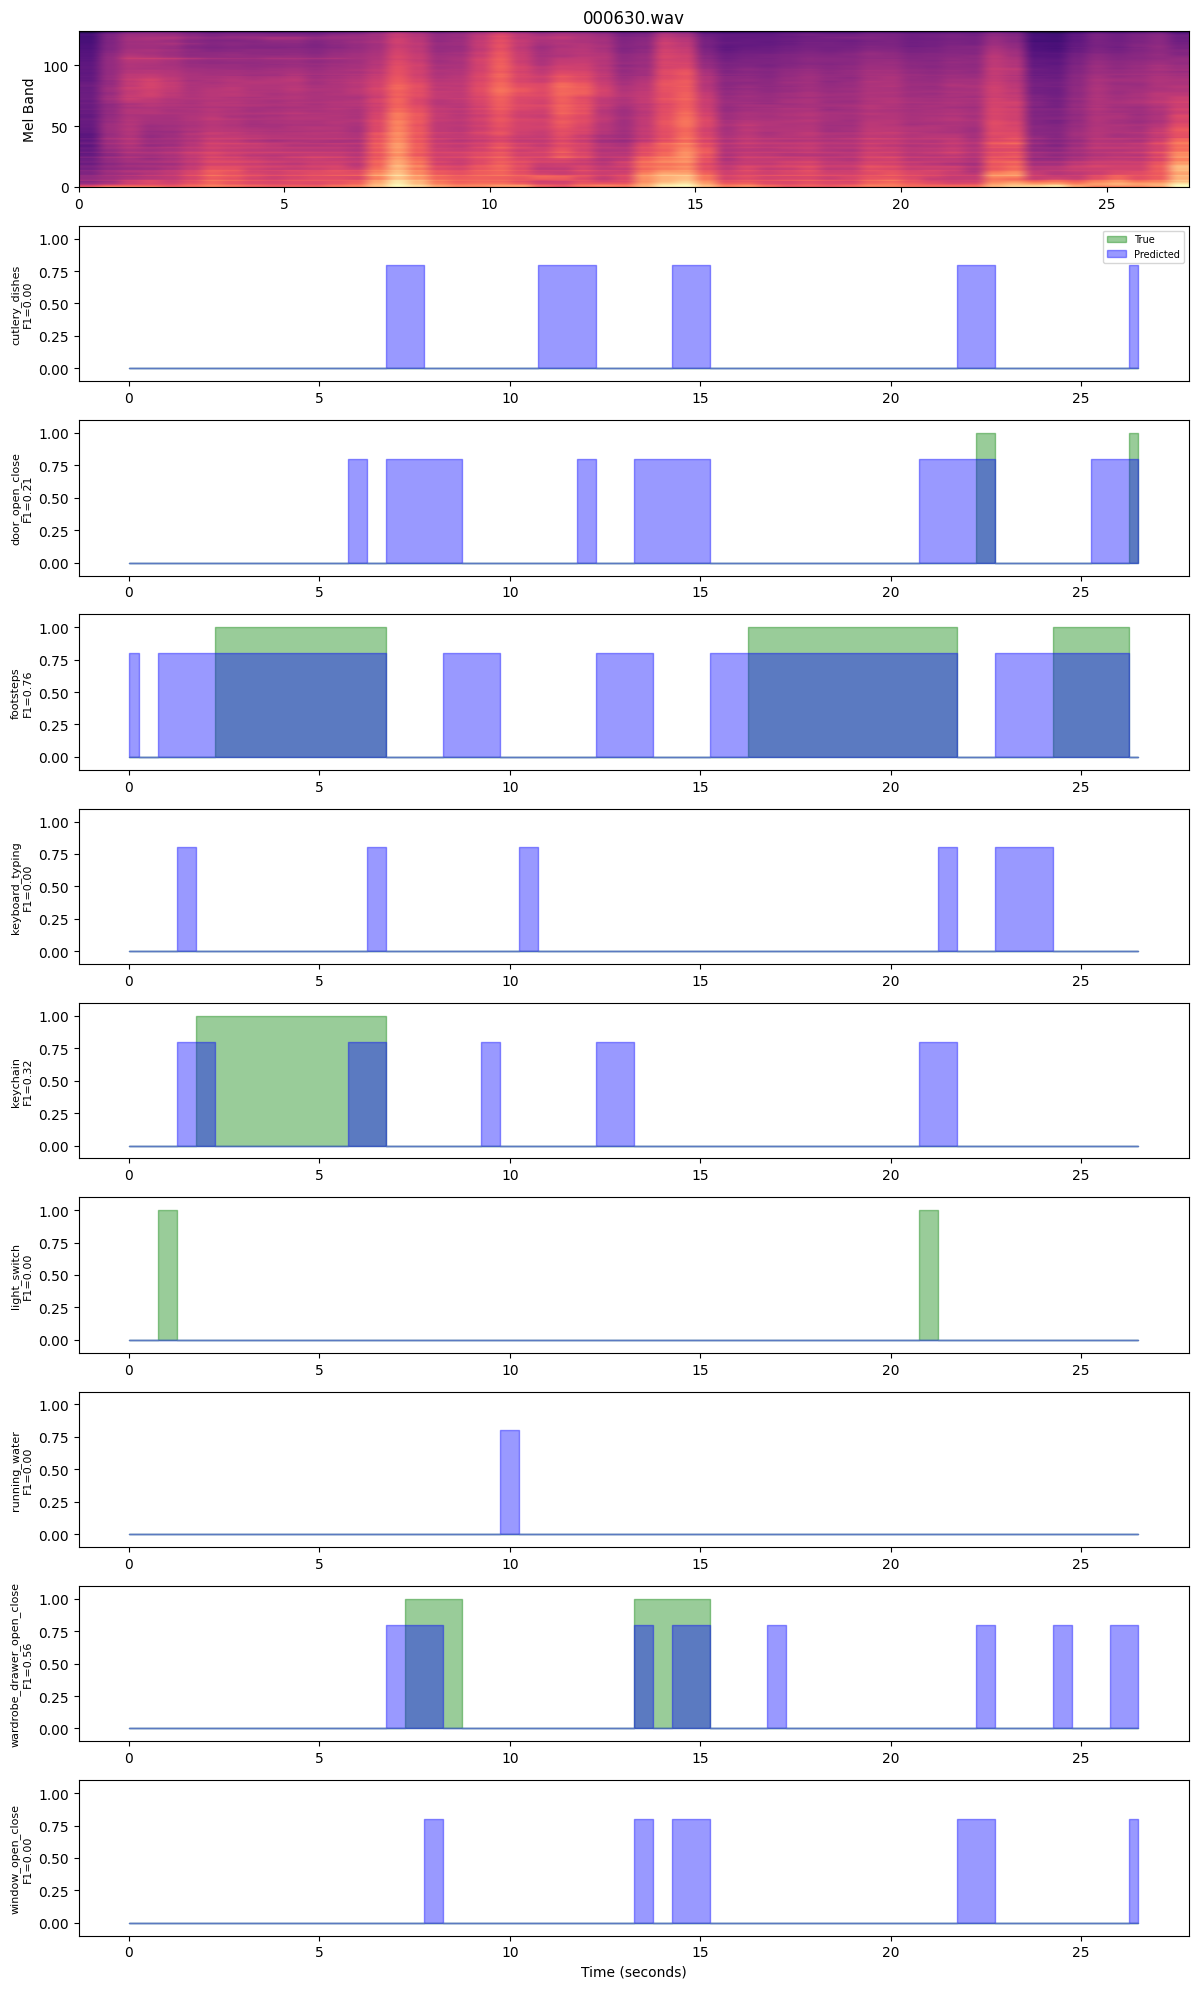


000630.wav:
  cutlery_dishes                      true=0 pred=10 F1=0.0000
  door_open_close                     true=2 pred=17 F1=0.2105
  footsteps                           true=24 pred=39 F1=0.7619
  keyboard_typing                     true=0 pred=7 F1=0.0000
  keychain                            true=10 pred=9 F1=0.3158
  light_switch                        true=2 pred=0 F1=0.0000
  running_water                       true=0 pred=1 F1=0.0000
  wardrobe_drawer_open_close          true=7 pred=11 F1=0.5556
  window_open_close                   true=0 pred=7 F1=0.0000


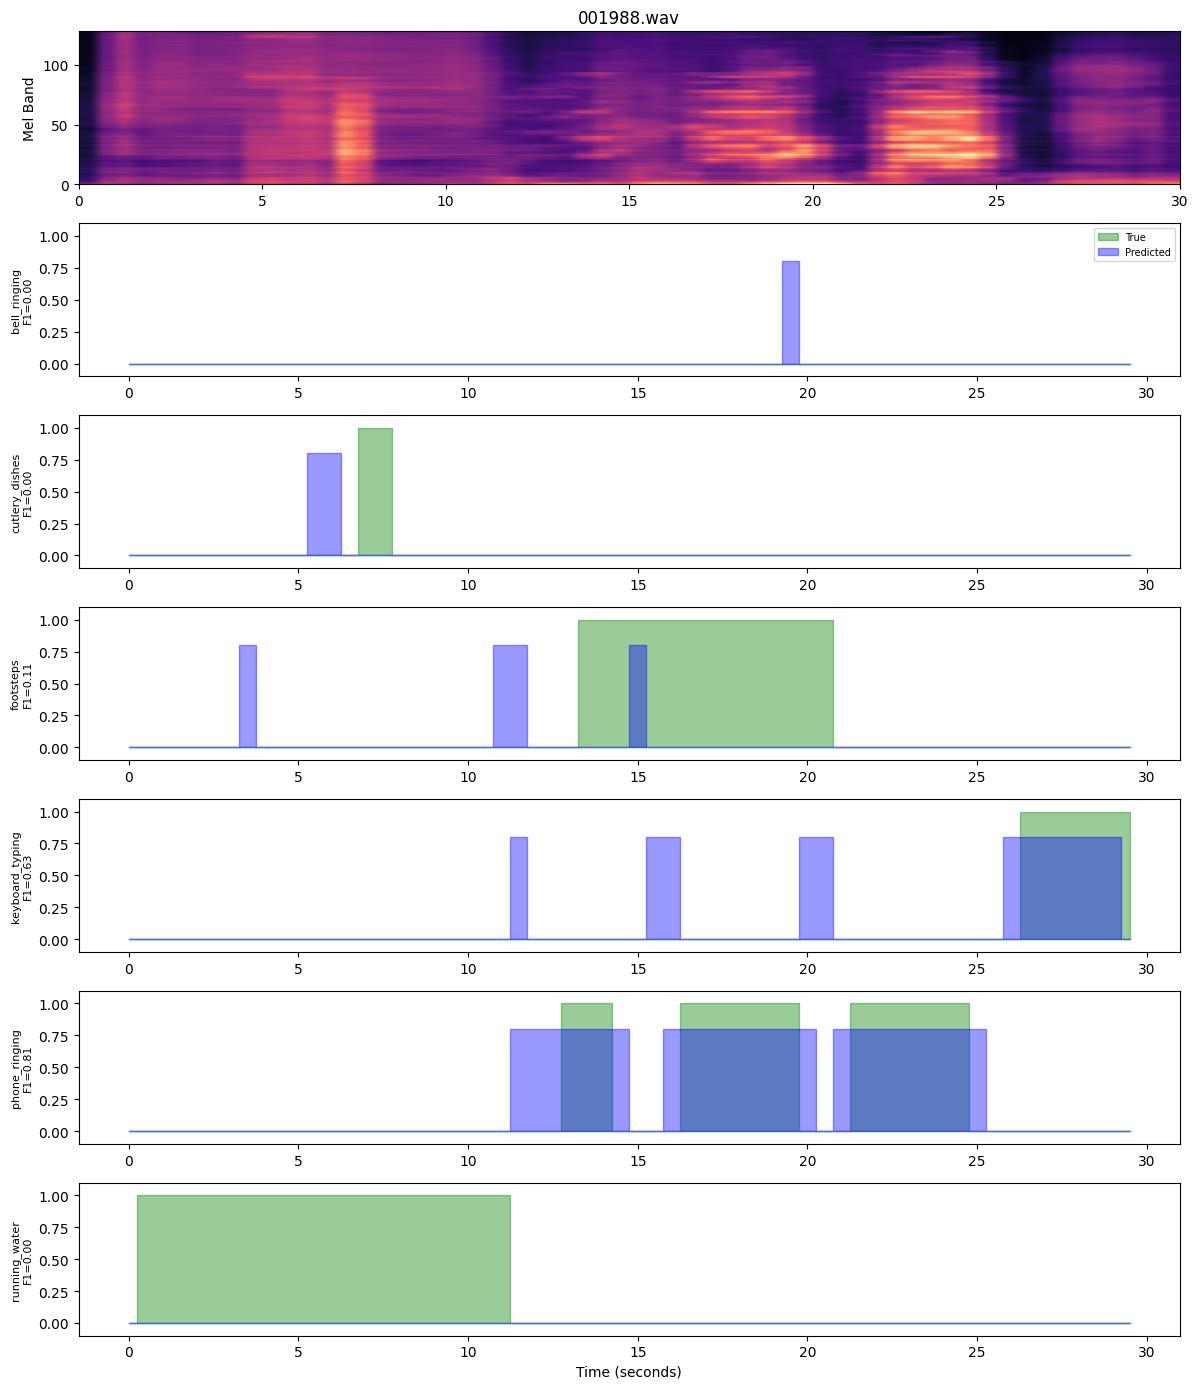


001988.wav:
  bell_ringing                        true=0 pred=1 F1=0.0000
  cutlery_dishes                      true=2 pred=2 F1=0.0000
  footsteps                           true=15 pred=4 F1=0.1053
  keyboard_typing                     true=7 pred=12 F1=0.6316
  phone_ringing                       true=17 pred=25 F1=0.8095
  running_water                       true=22 pred=0 F1=0.0000


In [13]:
# ================================================================
# QUESTION 4(a): CASE STUDY
# ================================================================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Find test files with multiple classes
test_unique_files = np.unique(filenames_test)
file_info = []
for fname in test_unique_files:
    mask = filenames_test == fname
    y_true = Y_test[mask]
    n_classes = (y_true.sum(axis=0) > 0).sum()
    classes = [class_names[i] for i in range(15) if y_true[:, i].sum() > 0]
    file_info.append((fname, n_classes, classes))

file_info.sort(key=lambda x: x[1], reverse=True)

print("Top 10 test files by number of classes:")
for fname, nc, cls in file_info[:10]:
    print(f"  {fname}: {nc} classes — {cls}")

case_file_1 = file_info[0][0]
case_file_2 = file_info[5][0]

def plot_case_study(filename):
    mask = filenames_test == filename
    y_true = Y_test[mask]
    y_pred = best_rf_clf.predict(X_test_scaled[mask])  # ← fixed
    
    # rest stays the same

    # Load spectrogram
    npz_path = dataset_path / 'audio_features' / filename.replace('.wav', '.npz')
    melspect = np.load(npz_path, allow_pickle=True)['melspect_mean']

    active = [c for c in range(15) if y_true[:, c].sum() > 0 or y_pred[:, c].sum() > 0]
    time_axis = np.arange(y_true.shape[0]) * 0.5

    fig, axes = plt.subplots(1 + len(active), 1, figsize=(12, 2 * (1 + len(active))))
    axes[0].imshow(melspect.T, aspect='auto', origin='lower', cmap='magma',
                   extent=[0, time_axis[-1]+0.5, 0, 128])
    axes[0].set_ylabel('Mel Band')
    axes[0].set_title(f'{filename}')

    for idx, c in enumerate(active):
        ax = axes[1 + idx]
        ax.fill_between(time_axis, 0, y_true[:, c], alpha=0.4, color='green', step='mid', label='True')
        ax.fill_between(time_axis, 0, y_pred[:, c] * 0.8, alpha=0.4, color='blue', step='mid', label='Predicted')
        f1 = f1_score(y_true[:, c], y_pred[:, c], zero_division=0)
        ax.set_ylabel(f'{class_names[c]}\nF1={f1:.2f}', fontsize=8)
        ax.set_ylim(-0.1, 1.1)
        if idx == 0:
            ax.legend(fontsize=7)
    axes[-1].set_xlabel('Time (seconds)')
    plt.tight_layout()
    plt.savefig(f'case_study_{filename.replace(".wav","")}.png', dpi=150)
    plt.show()

    print(f"\n{filename}:")
    for c in active:
        f1 = f1_score(y_true[:, c], y_pred[:, c], zero_division=0)
        print(f"  {class_names[c]:35s} true={int(y_true[:,c].sum())} pred={int(y_pred[:,c].sum())} F1={f1:.4f}")

plot_case_study(case_file_1)
plot_case_study(case_file_2)

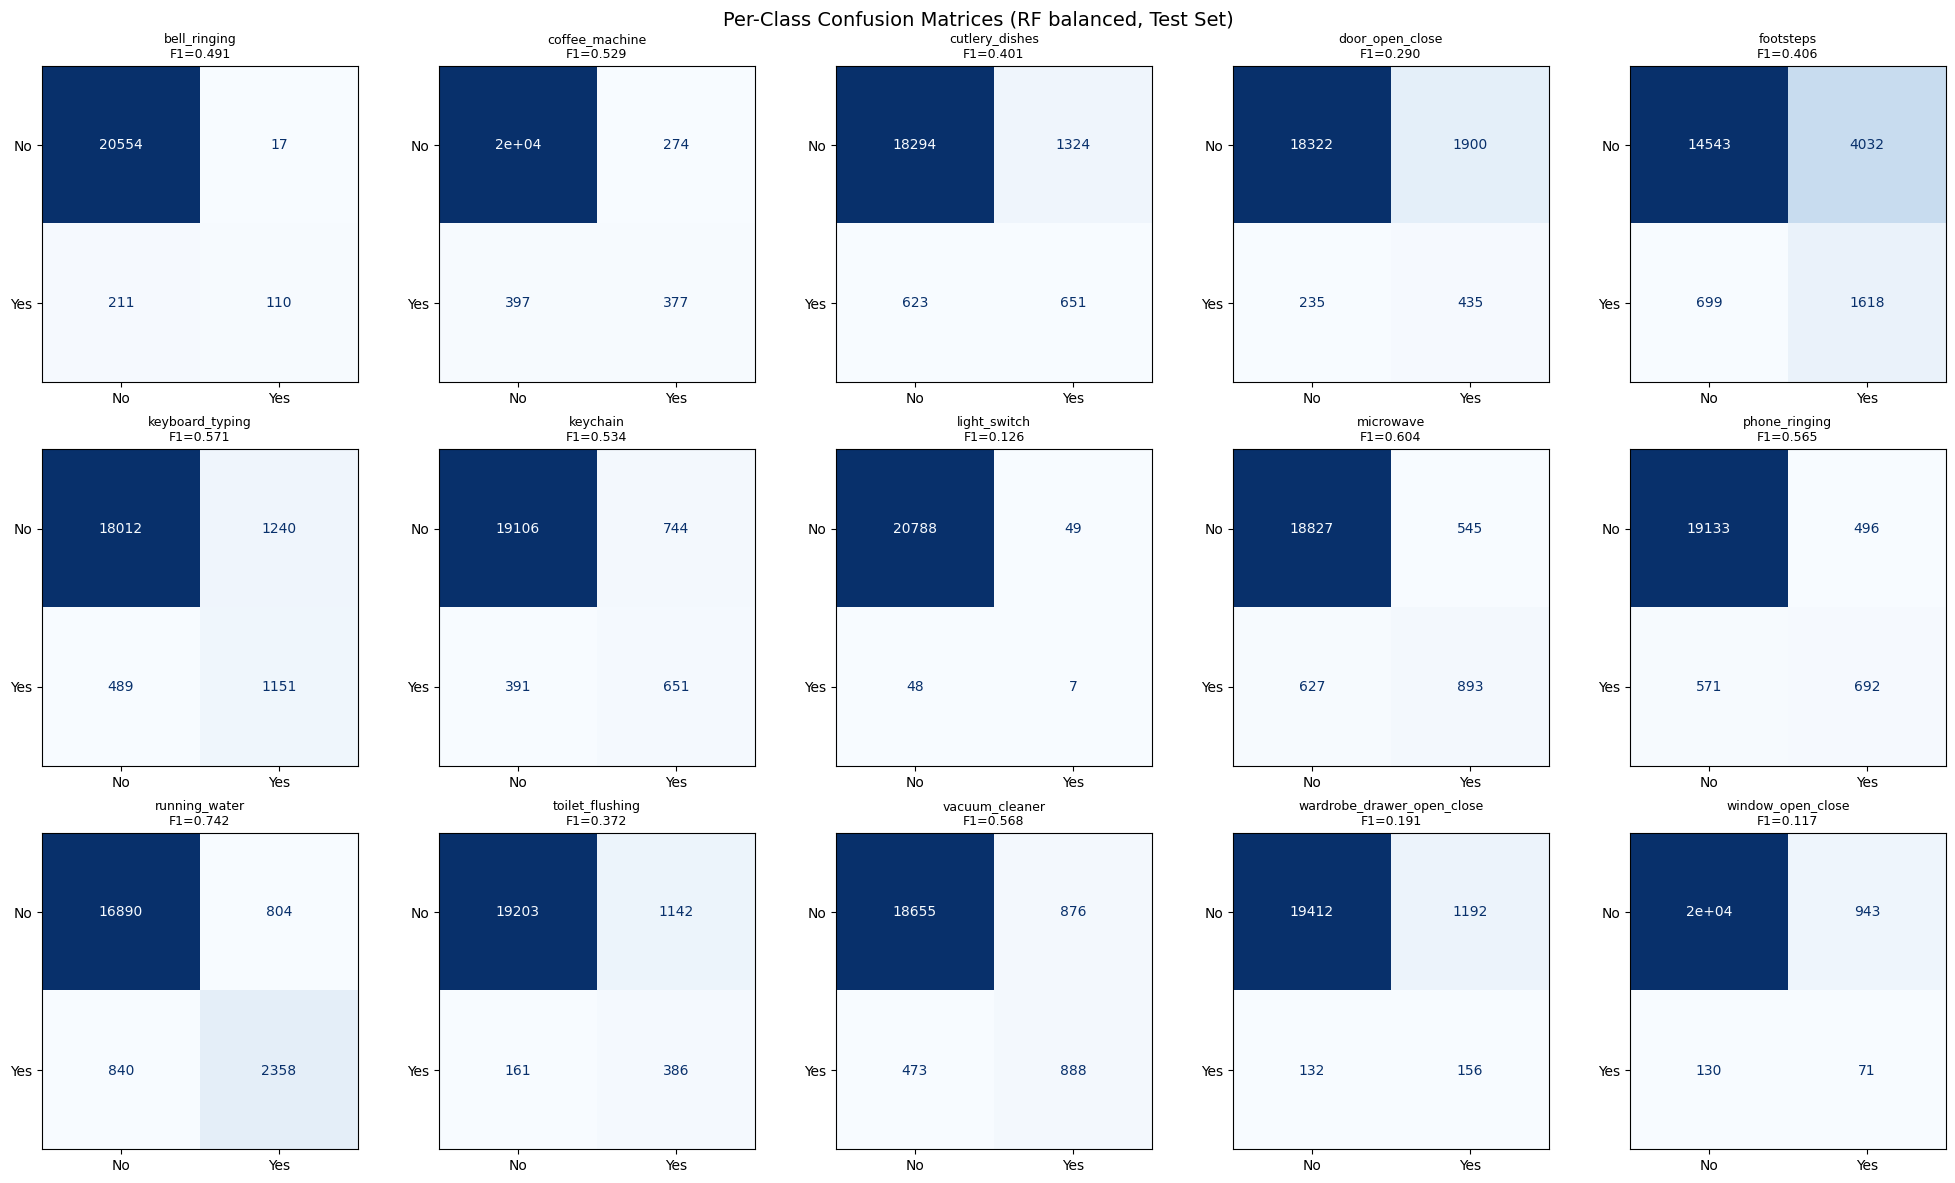


Classes ranked by F1:
  Class                                     F1  Support
  -------------------------------------------------------
  running_water                         0.7415     3198
  microwave                             0.6038     1520
  keyboard_typing                       0.5711     1640
  vacuum_cleaner                        0.5683     1361
  phone_ringing                         0.5647     1263
  keychain                              0.5343     1042
  coffee_machine                        0.5291      774
  bell_ringing                          0.4911      321
  footsteps                             0.4062     2317
  cutlery_dishes                        0.4007     1274
  toilet_flushing                       0.3720      547
  door_open_close                       0.2895      670
  wardrobe_drawer_open_close            0.1907      288
  light_switch                          0.1261       55
  window_open_close                     0.1169      201


In [14]:
# ================================================================
# QUESTION 4(b): CONFUSION MATRICES + REFLECTION
# ================================================================
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
fig.suptitle('Per-Class Confusion Matrices (RF balanced, Test Set)', fontsize=14)

per_class_f1 = []
for i, name in enumerate(class_names):
    ax = axes[i // 5, i % 5]
    cm = confusion_matrix(Y_test[:, i], Y_pred_rf_test[:, i])
    ConfusionMatrixDisplay(cm, display_labels=['No', 'Yes']).plot(ax=ax, cmap='Blues', colorbar=False)
    f1 = f1_score(Y_test[:, i], Y_pred_rf_test[:, i], zero_division=0)
    per_class_f1.append(f1)
    ax.set_title(f'{name}\nF1={f1:.3f}', fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

print("\nClasses ranked by F1:")
print(f"  {'Class':<35} {'F1':>8} {'Support':>8}")
print(f"  {'-'*55}")
for c in sorted(range(15), key=lambda c: per_class_f1[c], reverse=True):
    print(f"  {class_names[c]:<35} {per_class_f1[c]:>8.4f} {int(Y_test[:,c].sum()):>8}")